In [1]:
import pandas as pd
import numpy as np
import pickle 
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import json
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as PathEffects
from adjustText import adjust_text

# Volcano-specific palette (keep stable across manuscript)
VOLCANO_COLORS = {
    "background": "#B3B3B3",          # all genes
    "highlight_default": "#000000",   # if genes_of_interest is a single list
}

HIGHLIGHT_GROUP_COLORS = [
    "#0072B2",  # strong blue (safe)
    "#D55E00",  # vermillion (Okabe–Ito), NOT in your dataset palette
]

DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5":  "#66c2a5",  # greenish
    "Avatars K10": "#fc8d62",  # orange
    "CTGAN":  "#8da0cb",  # blue
    "Gaussian Copula":   "#e78ac3",  # pink
    "Synthpop":  "#a6d854",  # lime
    "TVAE":  "#ffd92f",  # yellow
}

# --- 1. Thông số cố định ---
FIXED_XLIM = (-3, 3)
FIXED_YLIM = (0, 5)

# Tính toán aspect ratio lý tưởng: (3 - (-3)) / (5 - 0) = 6/5 = 1.2
# Chúng ta sẽ ép các plot có cùng tỷ lệ khung hình này
TARGET_ASPECT = (FIXED_XLIM[1] - FIXED_XLIM[0]) / (FIXED_YLIM[1] - FIXED_YLIM[0])

plt.style.use(["science", "nature", "notebook"])
plt.rcParams.update({
    'text.usetex': False,
    'axes.edgecolor': '#333333',
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    'xtick.top': False,
    'ytick.right': False,
    # 'font.family': 'sans-serif'
})

def _prepare_volcano_df(
    dge_df: pd.DataFrame,
    gene_col = 'Gene',
    status_col = 'Status', 
    log2fc_col = 'Log2FC',
    significant_col = 'P_value',
    xlim = (-3, 3),
    ylim = (0, 5)
) -> pd.DataFrame:
    
    # 1. Work on a copy and filter by status immediately
    df = dge_df.copy()
    if status_col in df.columns:
        df = df[df[status_col] == 'ok']

    # 2. Calculate -log10 P-value safely
    eps = 1e-300
    # Use .values or .to_numpy() to avoid indexing issues during clip
    p_values = df[significant_col].astype(float)
    df["neglog10Significant"] = -np.log10(np.clip(p_values, eps, 1.0))

    # 3. Constrain X and Y (Note the parentheses around conditions)
    mask_x = (df[log2fc_col] >= xlim[0]) & (df[log2fc_col] <= xlim[1])
    mask_y = (df["neglog10Significant"] >= ylim[0]) & (df["neglog10Significant"] <= ylim[1])
    
    df_constrained = df[mask_x & mask_y].copy()

    return df_constrained


def plot_volcano_synchronized(ax, dataset_name, path, is_large=False):
    df_results = pd.read_csv(path)
    # Hàm của bạn đã clip sẵn về -3, 3 và 0, 5
    processed_df = _prepare_volcano_df(df_results, xlim=FIXED_XLIM, ylim=FIXED_YLIM)
    
    # 1. Vẽ các điểm
    ax.scatter(processed_df['Log2FC'], processed_df['neglog10Significant'],
               c="#E6E6E6", s=10 if is_large else 6, alpha=0.3, edgecolors='none', zorder=1)

    ax.axvline(0.0, color="#333333", lw=0.6, ls="--", alpha=0.2, zorder=2)
    ax.axhline(-np.log10(0.05), color="#333333", lw=0.6, ls="--", alpha=0.2, zorder=2)

    texts = []
    for idx, (group_name, gene_list) in enumerate(genes_interest_groups.items()):
        group_color = HIGHLIGHT_GROUP_COLORS[idx % len(HIGHLIGHT_GROUP_COLORS)]
        df_group = processed_df[processed_df['Gene'].isin(gene_list)]
        
        ax.scatter(df_group['Log2FC'], df_group['neglog10Significant'],
                   c=group_color, s=45 if is_large else 20, 
                   edgecolor='white', linewidth=0.5, zorder=5, label=group_name if is_large else "")
        
        if is_large:
            for _, row in df_group.iterrows():
                t = ax.text(row['Log2FC'], row['neglog10Significant'], row['Gene'], 
                            fontsize=9, fontweight='600', color=group_color)
                t.set_path_effects([PathEffects.withStroke(linewidth=2, foreground='white')])
                texts.append(t)

    if is_large and texts:
        adjust_text(texts, ax=ax, only_move={'points':'y', 'texts':'xy'},
                    arrowprops=dict(arrowstyle='-', color='#666666', lw=0.5))

    # 2. Đồng bộ X/Y Limit tuyệt đối
    ax.set_xlim(FIXED_XLIM)
    ax.set_ylim(FIXED_YLIM)
    
    # 3. QUAN TRỌNG: Đảm bảo tỷ lệ khung hình giống hệt nhau
    # 'box-forced' giúp các trục có cùng hình dạng dù kích thước vật lý khác nhau
    ax.set_box_aspect(1/TARGET_ASPECT) 

    # 4. Styling
    title_color = DATASET_COLORS.get(dataset_name, "black")
    ax.set_title(dataset_name, fontsize=12, fontweight="bold", color=title_color)
    
    if is_large:
        ax.set_xlabel('Log2FC', fontsize=10, fontweight='bold')
        ax.set_ylabel('-log10(P-value)', fontsize=10, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8, frameon=True)
    else:
        ax.tick_params(labelsize=8)

----0----


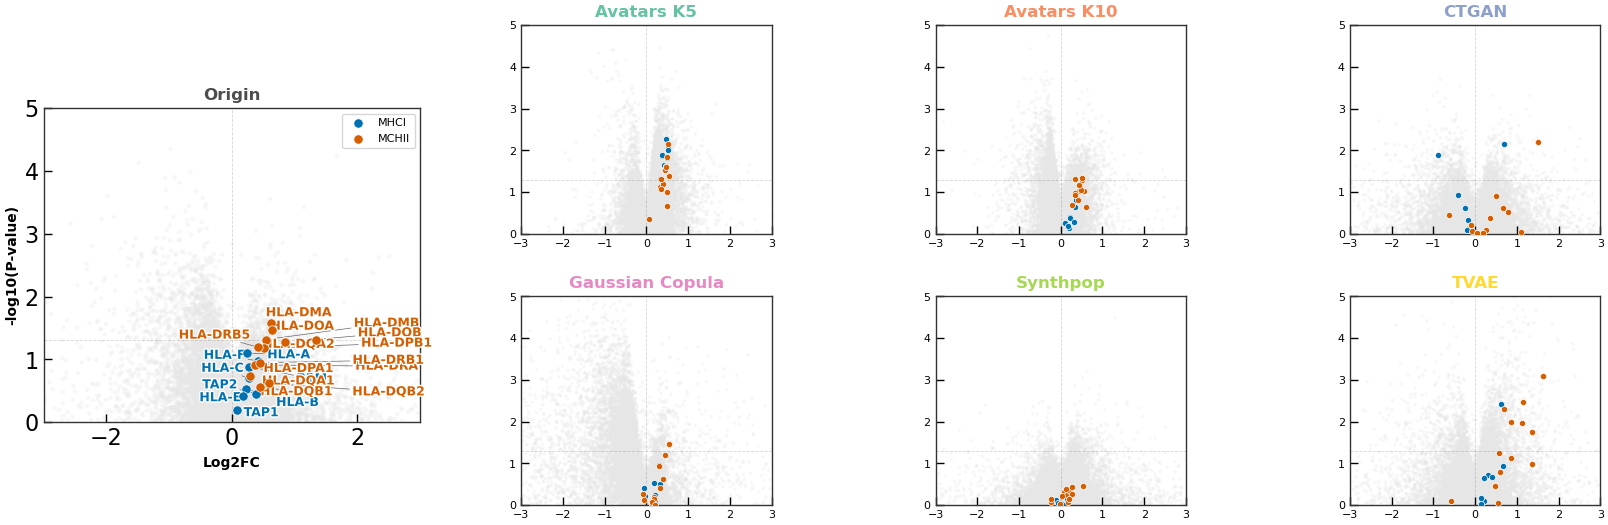

----1----


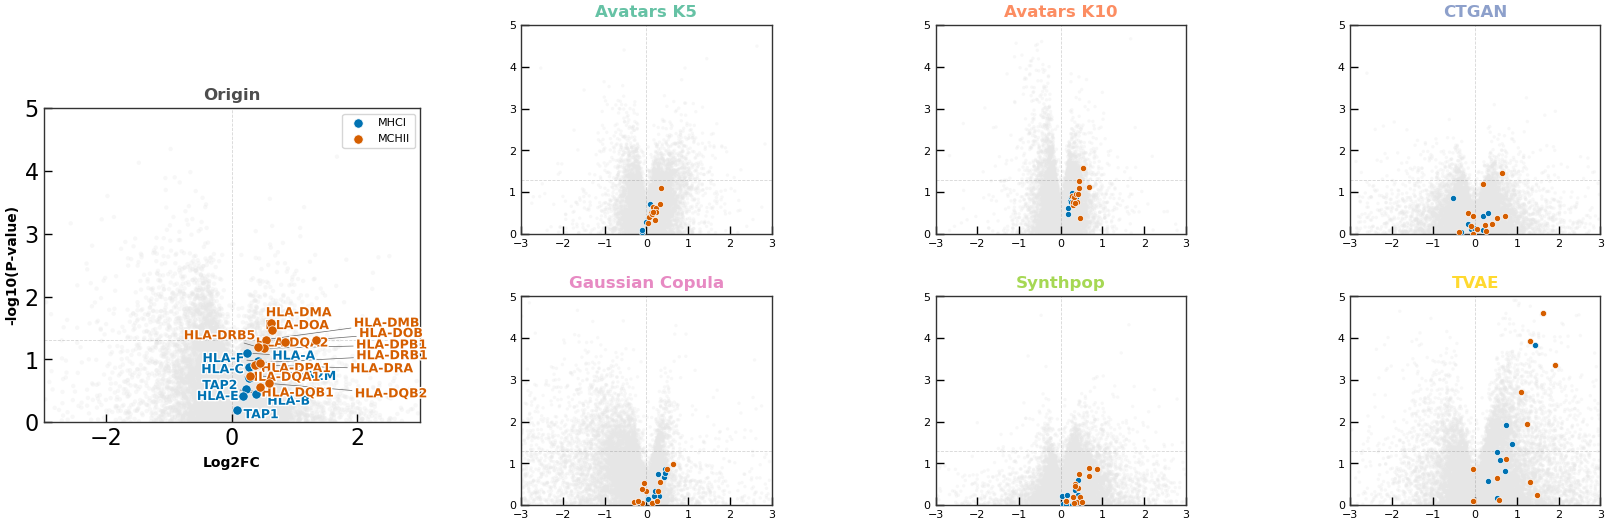

----2----


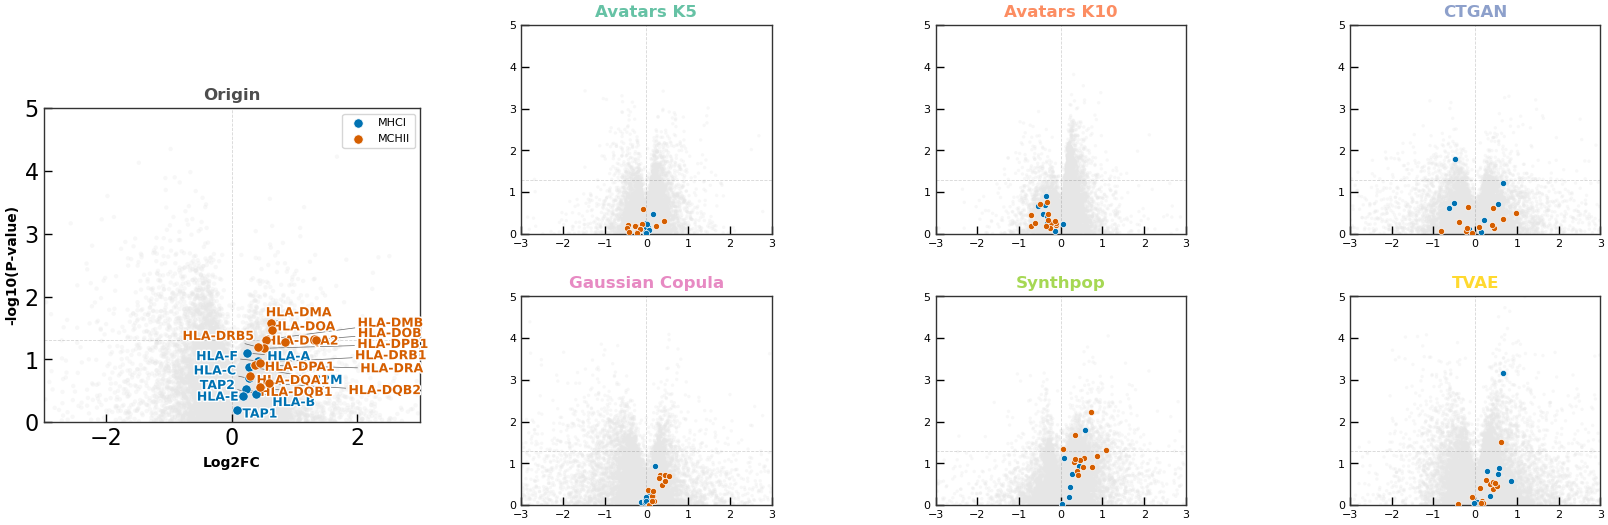

----3----


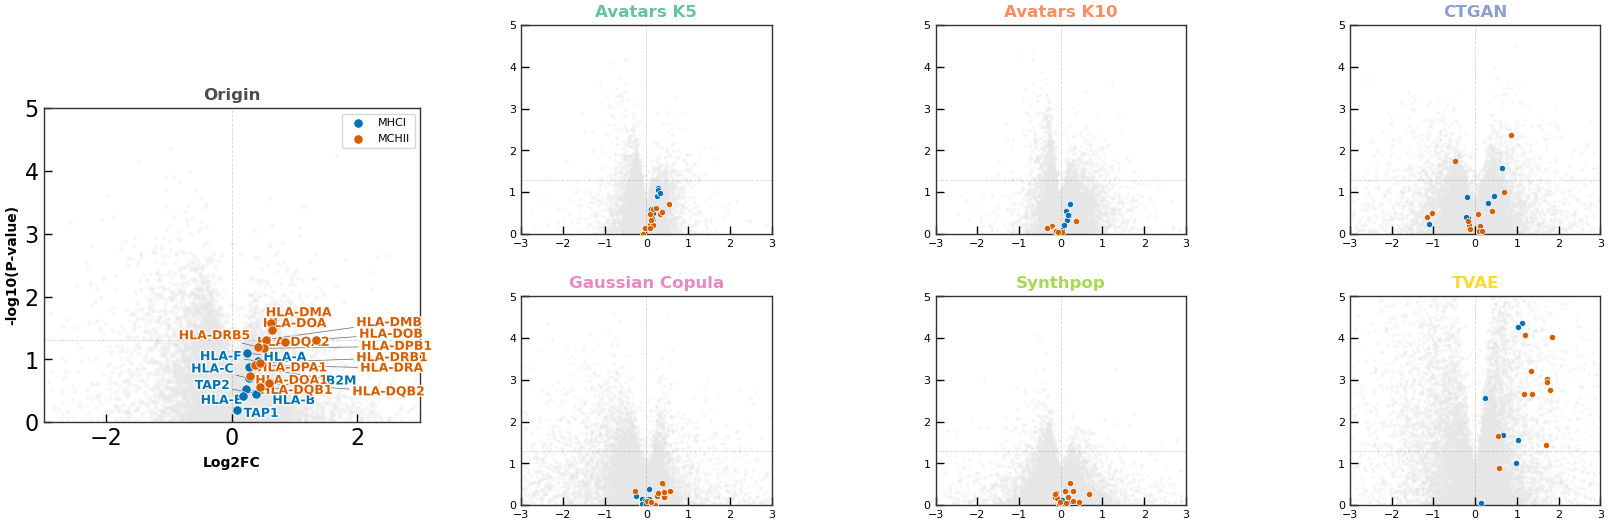

----42----


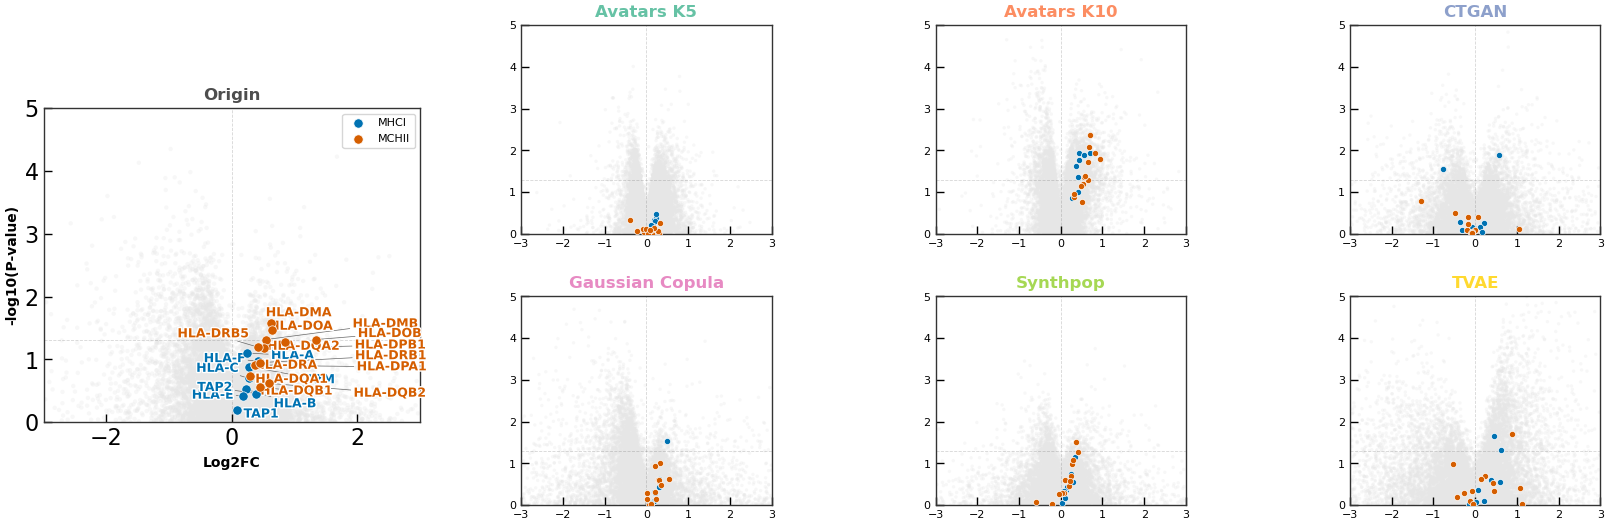

In [2]:
mhc1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
mhc2 = ['HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
        'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
        'HLA-DRB5']
genes_interest_groups = {"MHCI":mhc1, "MCHII": mhc2}

seeds = [0,1,2,3,42]
for seed in seeds:
    print(f"----{seed}----")
    path_dict = {
        'Origin': f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_Origin.csv',
        'Avatars K5':  f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_avatarsk5_{seed}.csv',
        'Avatars K10':  f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_avatarsk10_{seed}.csv',
        'CTGAN':  f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_ctgan_{seed}.csv',
        'Gaussian Copula':  f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_gaussiancopula_{seed}.csv',
        'Synthpop': f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_synthpop_{seed}.csv',
        'TVAE': f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_tvae_{seed}.csv',
    }
    
    fig = plt.figure(figsize=(18, 6))
    
    # wspace và hspace nhỏ để các plot trông gần gũi và chuyên nghiệp hơn
    gs = gridspec.GridSpec(2, 4, figure=fig, wspace=0.1, hspace=0.3)
    
    # Vẽ Origin
    ax_large = fig.add_subplot(gs[:, 0])
    plot_volcano_synchronized(ax_large, 'Origin', path_dict['Origin'], is_large=True)
    
    # Vẽ các ô nhỏ
    remaining = [d for d in path_dict.keys() if d != 'Origin']
    for i, name in enumerate(remaining):
        row, col = divmod(i, 3)
        ax_small = fig.add_subplot(gs[row, col + 1])
        plot_volcano_synchronized(ax_small, name, path_dict[name], is_large=False)
    
    # Sử dụng subplot_adjust để giảm lề thừa nếu cần
    plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1)
    # fig.savefig(f'Volcanoplot/VolcanoPlot_Melanoma_{seed}.pdf', dpi=300, bbox_inches='tight')
    fig.savefig(f'Volcanoplot/VolcanoPlot_Melanoma_{seed}.png', dpi=300, bbox_inches='tight')
    plt.show()

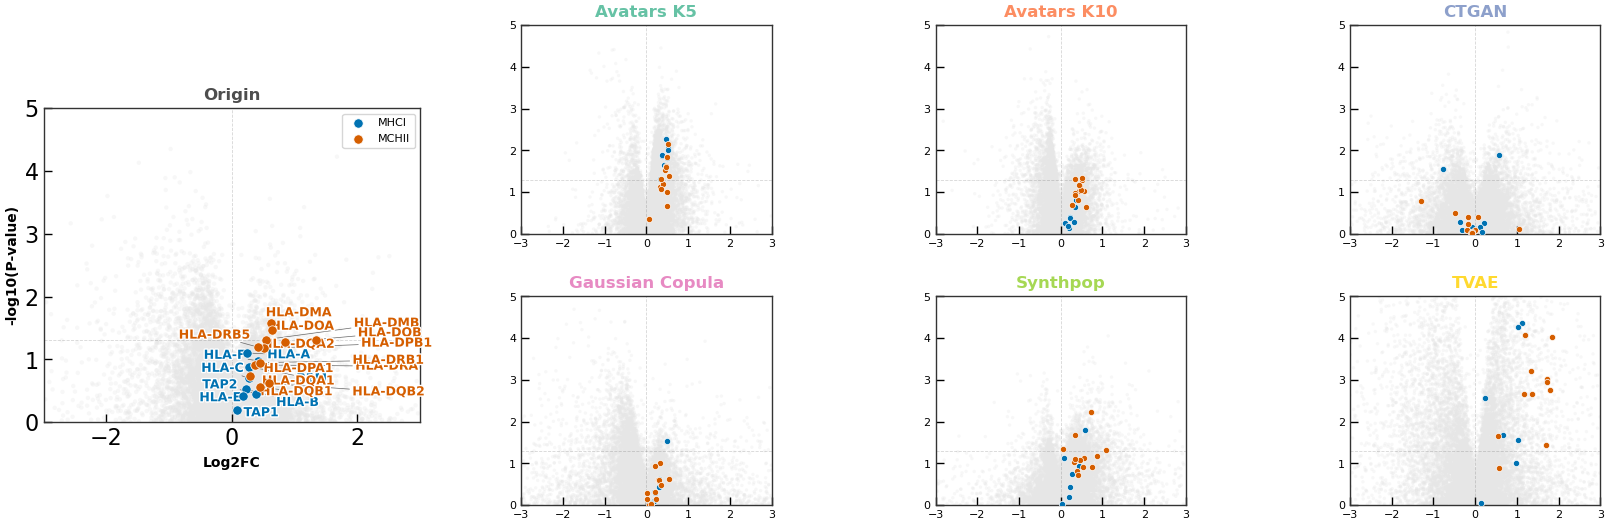

In [3]:
representative_path_dict = {
    'Origin': f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_42/DGE_Origin.csv',
    'Avatars K5':  f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_0/DGE_avatarsk5_0.csv',
    'Avatars K10':  f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_0/DGE_avatarsk10_0.csv',
    'CTGAN':  f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_42/DGE_ctgan_42.csv',
    'Gaussian Copula':  f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_42/DGE_gaussiancopula_42.csv',
    'Synthpop': f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_2/DGE_synthpop_2.csv',
    'TVAE': f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_3/DGE_tvae_3.csv',
}
mhc1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
mhc2 = ['HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
        'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
        'HLA-DRB5']
genes_interest_groups = {"MHCI":mhc1, "MCHII": mhc2}

fig = plt.figure(figsize=(18, 6))

# wspace và hspace nhỏ để các plot trông gần gũi và chuyên nghiệp hơn
gs = gridspec.GridSpec(2, 4, figure=fig, wspace=0.1, hspace=0.3)

# Vẽ Origin
ax_large = fig.add_subplot(gs[:, 0])
plot_volcano_synchronized(ax_large, 'Origin', representative_path_dict['Origin'], is_large=True)

# Vẽ các ô nhỏ
remaining = [d for d in representative_path_dict.keys() if d != 'Origin']
for i, name in enumerate(remaining):
    row, col = divmod(i, 3)
    ax_small = fig.add_subplot(gs[row, col + 1])
    plot_volcano_synchronized(ax_small, name, representative_path_dict[name], is_large=False)

# Sử dụng subplot_adjust để giảm lề thừa nếu cần
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1)
# fig.savefig(f'Volcanoplot/VolcanoPlot_Melanoma_best.pdf', dpi=300, bbox_inches='tight')
plt.show()

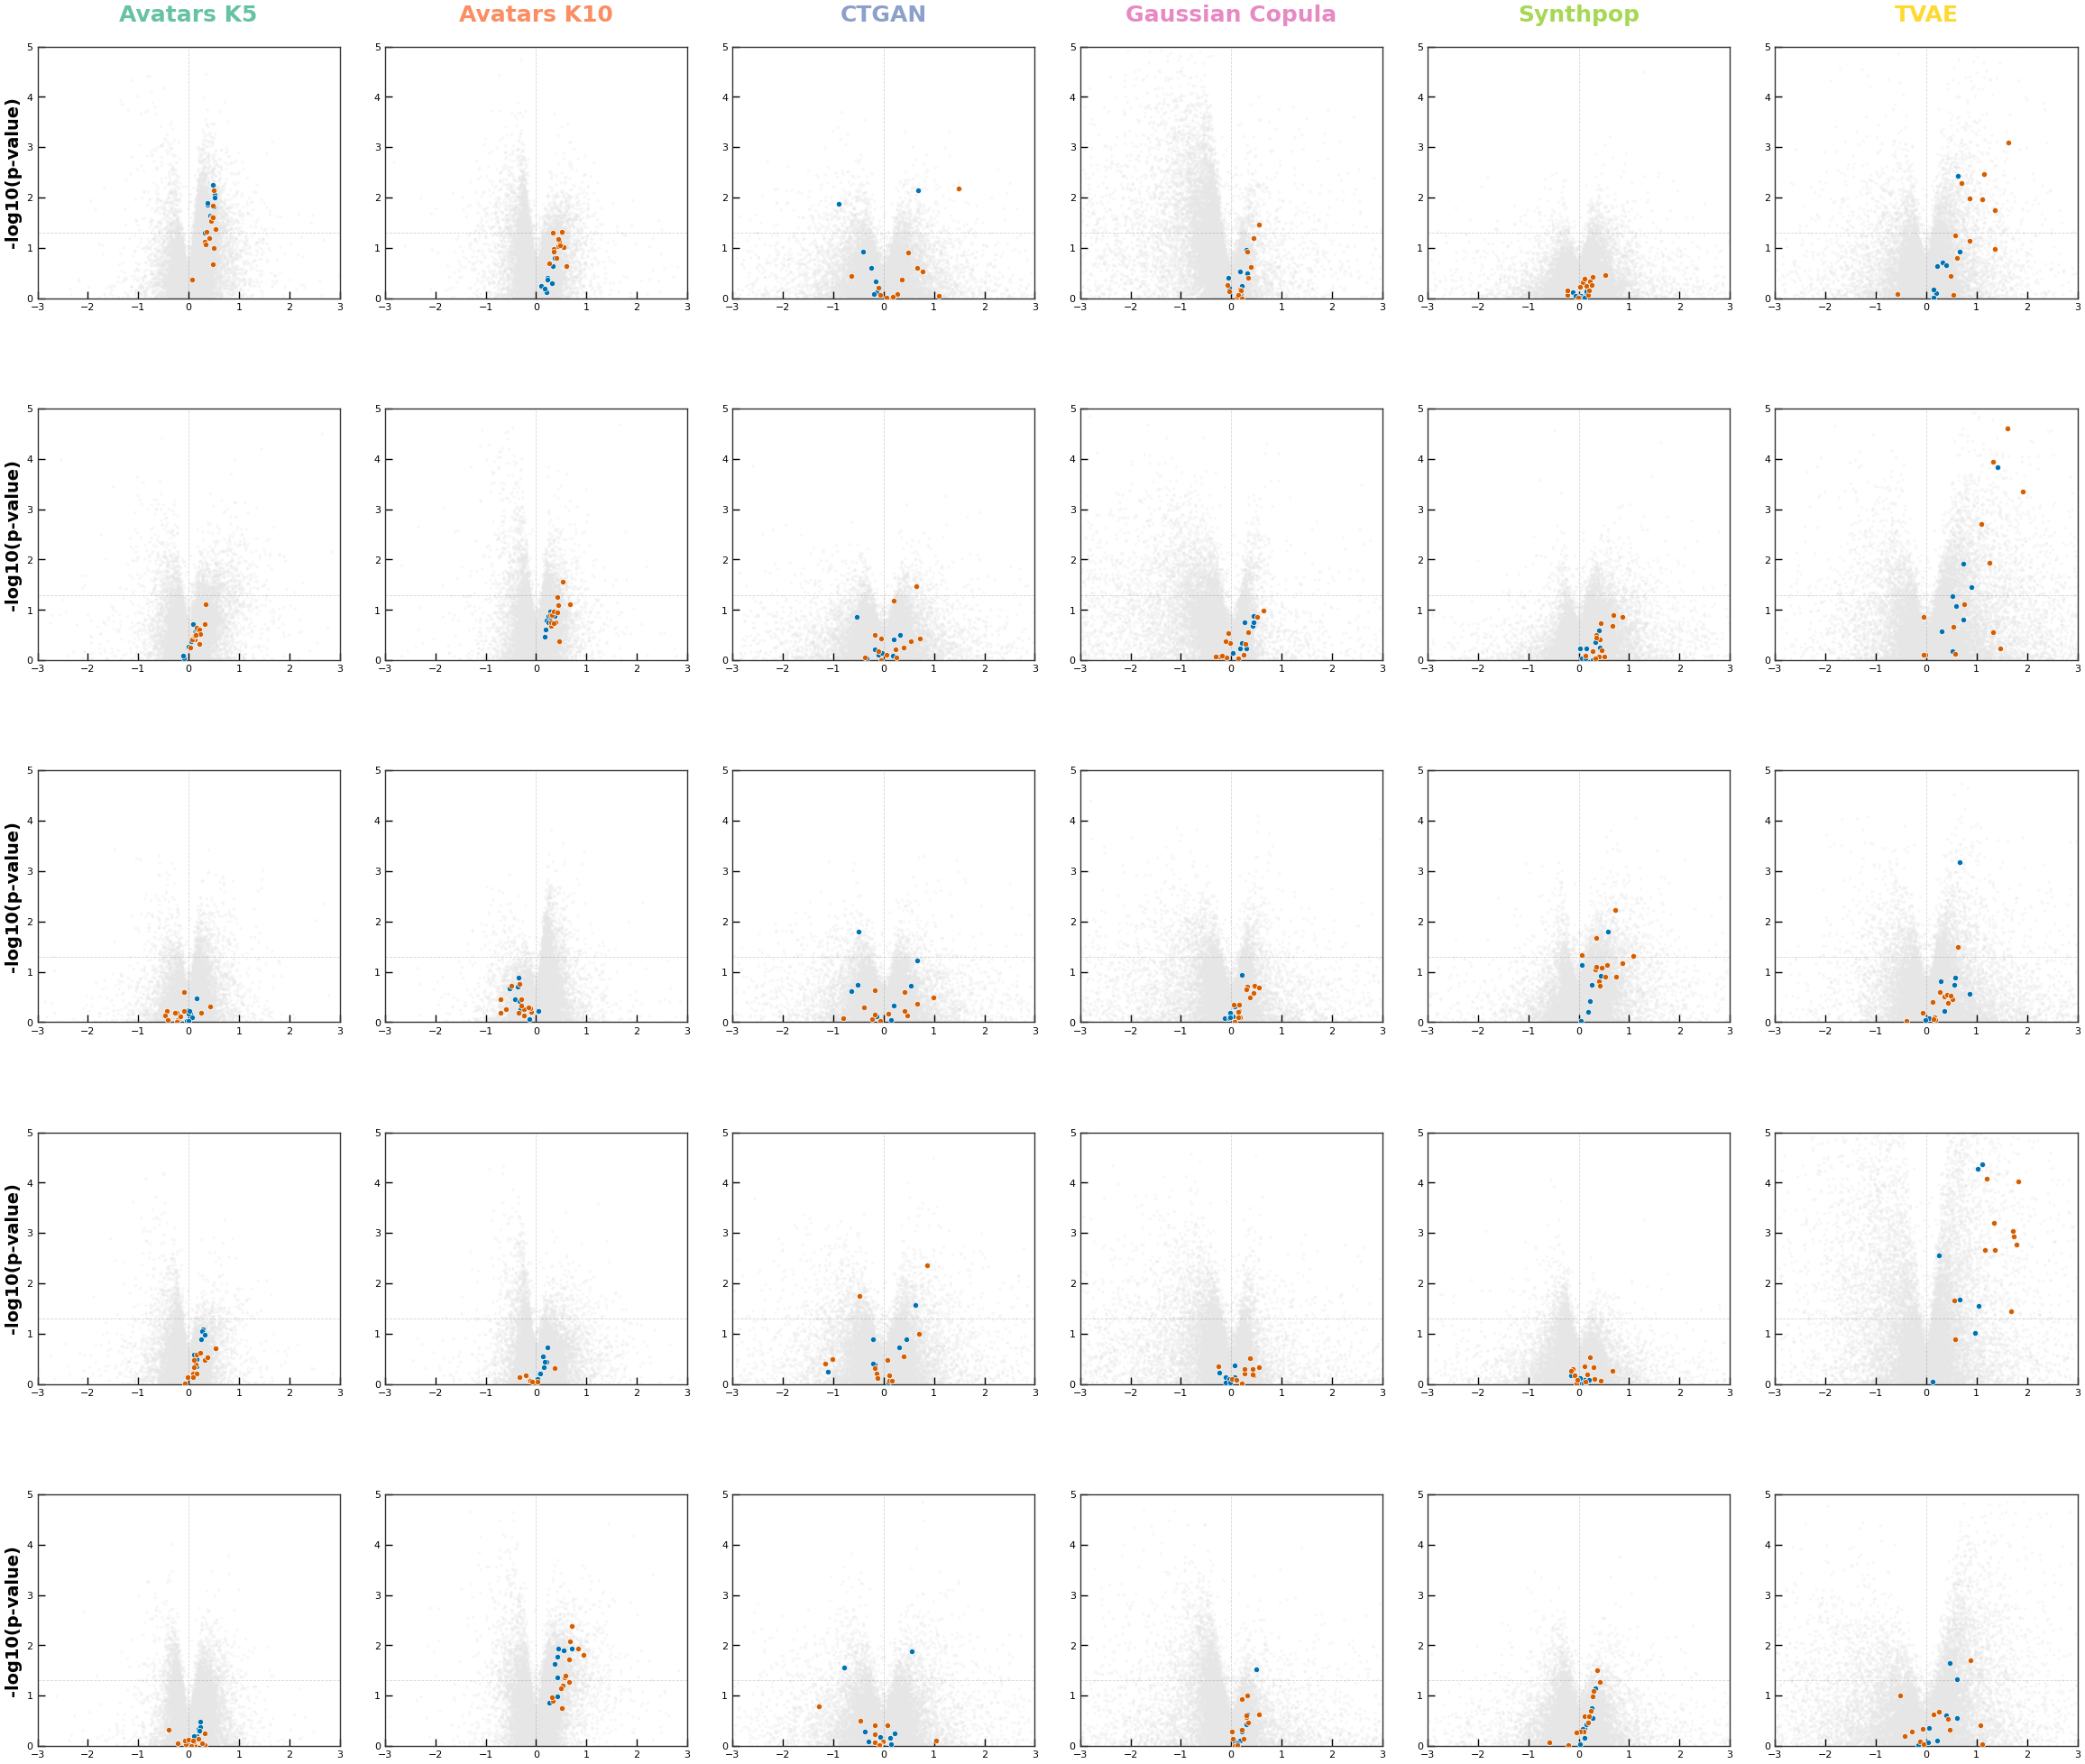

In [6]:
import matplotlib.pyplot as plt
from matplotlib import gridspec


seeds = [0, 1, 2, 3, 42]
methods = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']

fig = plt.figure(figsize=(26, 22))

gs = gridspec.GridSpec(len(seeds), len(methods), figure=fig, wspace=0.15, hspace=0.3)

for row_idx, seed in enumerate(seeds):
    path_dict = {
        'Avatars K5':      f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_avatarsk5_{seed}.csv',
        'Avatars K10':     f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_avatarsk10_{seed}.csv',
        'CTGAN':           f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_ctgan_{seed}.csv',
        'Gaussian Copula': f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_gaussiancopula_{seed}.csv',
        'Synthpop':        f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_synthpop_{seed}.csv',
         'TVAE':        f'../Melanoma/NarrowUtility/DGE/CRPR_PD/Seed_{seed}/DGE_tvae_{seed}.csv',
    }

    for col_idx, method_name in enumerate(methods):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        
        m_color = DATASET_COLORS.get(method_name, "black")
        
        plot_volcano_synchronized(
            ax, 
            "",
            path_dict[method_name], 
            is_large=False
        )


        if row_idx == 0:
            ax.set_title(method_name, fontsize=18, fontweight='bold', color=m_color, pad=20)

        
        if col_idx == 0:
            ax.set_ylabel(f"-log10(p-value)", fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel("") 
      
        ax.grid(False) 


plt.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.05)
fig.savefig('Volcanoplot/Combined_Volcano_Replicates.png', dpi=300, bbox_inches='tight')
plt.show()